# Chapter 2 

## First neural network

### Loading dataset(MNIST)

In [1]:
# Loading the MNIST dataset in Keras

from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

/Users/mitchell/Desktop/Github Repos/AI-Practice/Deep Learning/Deep Learning with Python/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
print(train_images.shape)
print(len(train_labels))

print(test_images.shape)
print(len(test_labels))


(60000, 28, 28)
60000
(10000, 28, 28)
10000


### Building the model

In [3]:
# The network architecture

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [4]:
# The compilation step

model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

### Data preprocessing

In [5]:
# Preprocess the data

train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

### Model training

In [6]:
# Fit the model

model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9231 - loss: 0.2650
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9679 - loss: 0.1078
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9793 - loss: 0.0712
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9845 - loss: 0.0514
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9884 - loss: 0.0394


### Model predictions

In [7]:
# Make predictions

test_digits = test_images[0:10]
predictions = model.predict(test_digits)
print(predictions[0])
print(predictions[0].argmax())
print(predictions[0][7])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[8.9516163e-08 2.0070564e-08 1.1895562e-05 2.8243096e-04 1.3989440e-10
 8.1332239e-08 2.3720515e-11 9.9969757e-01 5.7248695e-07 7.2564540e-06]
7
0.99969757


In [8]:
# Evaluating on new data

test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 504us/step - accuracy: 0.9799 - loss: 0.0666
test_acc: 0.9799000024795532


## Data representations

### Scalars, vectors, matrices, and tensors

A tensor that contains only one number is called a _scalar_ (or scalar tensor, or rank-0
tensor, or 0D tensor). In NumPy, a `float32` or `float64` number is a scalar tensor (or
scalar array). You can display the number of axes of a NumPy tensor via the `ndim` attribute;

The number of axes of a tensor is also called its _rank_.

In [9]:
# Scalars

import numpy as np

x = np.array(12)

print(x)
print(x.ndim)

12
0


An array of numbers is called a _vector_, or rank-1 tensor, or 1D tensor.


In [10]:
x = np.array([12, 3, 6, 14, 7])

print(x)
print(x.ndim)

[12  3  6 14  7]
1


_Dimensionality_ can denote either the number of entries along a specific axis (as in the case of our 5D vector) or the number of axes in a tensor (such as a 5D tensor), which can be confusing at times. In the latter case, it’s technically more correct to talk about a tensor of rank 5 (the rank of a tensor being the number of axes), but the ambiguous notation 5D tensor is common regardless.

An array of vectors is a _matrix_, or rank-2 tensor, or 2D tensor. A matrix has two axes
(often referred to as rows and columns).

The entries from the first axis are called the _rows_, and the entries from the second axis
are called the _columns_.

In [11]:
x = np.array([
    [5, 78, 2, 34, 0],
    [6, 79, 3, 35, 1],
    [7, 80, 4, 36, 2]
])

print(x)
print(x.ndim)

[[ 5 78  2 34  0]
 [ 6 79  3 35  1]
 [ 7 80  4 36  2]]
2


If you pack such matrices in a new array, you obtain a rank-3 tensor (or 3D tensor), which you can visually interpret as a cube of numbers.

In [12]:
x = np.array([[[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]]])

print(x)
print(x.ndim)


[[[ 5 78  2 34  0]
  [ 6 79  3 35  1]
  [ 7 80  4 36  2]]

 [[ 5 78  2 34  0]
  [ 6 79  3 35  1]
  [ 7 80  4 36  2]]

 [[ 5 78  2 34  0]
  [ 6 79  3 35  1]
  [ 7 80  4 36  2]]]
3


A tensor is defined by three key attributes:
* **Number of axes (rank)** — This is also called the tensor’s *ndim* in Python libraries such as NumPy or TensorFlow.
* **Shape** — This is a tuple of integers that describes how many dimensions the tensor has along each axis, whereas a scalar has an empty shape, `()`.
* **Data type** (usually called `dtype` in Python libraries) — This is the type of the data
contained in the tensor;

5


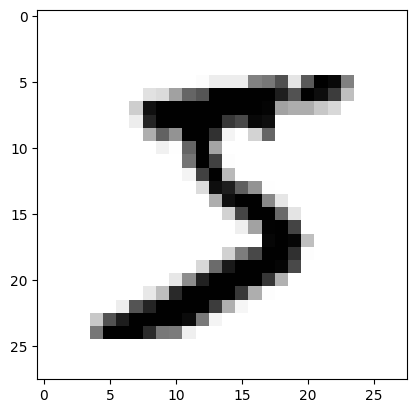

In [ ]:
# Displaying the first digit in the training set

import matplotlib.pyplot as plt

digit = train_images[0]
reshaped_digit = digit.reshape(28, 28)
print(train_labels[0])

# the `plt.imshow()` function expects the input array to be in a valid image format, typically a 2D array of shape `(height, width)` for grayscale or `(height, width, channels)` for color images.
plt.imshow(reshaped_digit, cmap=plt.cm.binary)
plt.show()

#### Tensor slicing

Selecting a specific digit alongside the first axis using the syntax `train_images[i]`. 

Selecting specific elements in a tensor is called _tensor slicing_.

Note that `:` is equivalent to selecting the entire axis.

It’s also possible to use **negative** indices. Much like negative indices in Python lists, they indicate **a position relative to the end of the current axis**.

In [14]:
# Tensor slicing
train_images = train_images.reshape((60000, 28, 28))
test_images = test_images.reshape((10000, 28, 28))

my_slice = train_images[10:100]
print(my_slice.shape)
my_slice = train_images[10:100, :, :]
print(my_slice.shape)
my_slice = train_images[10:100, 0:28, 0:28]
print(my_slice.shape)

(90, 28, 28)
(90, 28, 28)
(90, 28, 28)


#### Batch axis

In general, the first axis (axis 0, because indexing starts at 0) in all data tensors in deep learning will be the _samples axis_ (sometimes called the _samples dimension_).

In addition, deep learning models **don’t** process an **entire dataset at once**; rather, they break the data into small batches.

When considering such a batch tensor, the first axis (axis 0) is called the batch axis or batch dimension.

In [17]:
# a batch size of 128
batch = train_images[:128]
print(batch.shape)

(128, 28, 28)


#### Real-world examples of data tensors

* _Vector data_ — **Rank-2** tensors of shape `(samples, features)`, where each sample
is a vector of numerical attributes (“features”).
* _Timeseries data or sequence data_ — **Rank-3** tensors of shape `(samples, timesteps,
features)`, where each sample is a sequence (of length timesteps) of feature
vectors.
* _Images_ — **Rank-4** tensors of shape `(samples, height, width, channels)`, where
each sample is a 2D grid of pixels, and each pixel is represented by a vector of
values (“channels”)
* _Video_ — **Rank-5** tensors of shape `(samples, frames, height, width, channels)`,
where each sample is a sequence (of length frames) of images

The time axis is always the second axis (axis of index 1) by convention.

A **video** can be understood as **a sequence of frames**, each frame being a color image. Videos in real life aren’t stored in `float32`, and they’re typically compressed by a large factor (such as in the MPEG format).

There are two conventions for shapes of image tensors: the _channels-last_ convention (which is standard in TensorFlow) and the _channels-first_ convention (which is increasingly falling out of favor). The Keras API provides support for both formats.


### Tensor operations

All transformations learned by deep neural networks can be reduced to a handful of _tensor operations_ (or _tensor functions_) applied to tensors of numeric data.

`output = relu(dot(input, W) + b)`

#### Element-wise operations

The `relu` operation and addition are **element-wise operations**: operations that are
applied independently to each entry in the tensors being considered. This means these operations are highly amenable to massively **parallel implementations** (_vectorized
implementations_, a term that comes from the vector processor supercomputer architecture from the 1970–90 period).

You can implement naive element-wise operations via `for` loop in Python

In [ ]:
def naive_relu(x):
    assert len(x.shape) == 2

    x = x.copy() # avoid overwriting the input tensor
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] = max(x[i, j], 0)
    
    return x

In [19]:
def naive_add(x, y):
    assert len(x.shape) == 2
    assert x.shape == y.shape

    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[i, j]
    
    return x

In practice, when dealing with NumPy arrays, these operations are available as **well-optimized built-in NumPy functions**, which themselves delegate the heavy lifting to a **Basic Linear Algebra Subprograms(BLAS)** implementation. 

BLAS are **low-level, highly parallel, efficient tensor-manipulation routines** that are typically implemented in Fortran or C.

In [23]:
import time 

x = np.random.random((20, 100))
y = np.random.random((20, 100))

t0 = time.time()
for _ in range(1000):
    z = x + y
    z = np.maximum(z, 0.)

print("Took: {0:.2f} s".format(time.time() - t0))

Took: 0.00 s


In [24]:
t0 = time.time() 
for _ in range(1000):
    z = naive_add(x, y)
    z = naive_relu(z) 
print("Took: {0:.2f} s".format(time.time() - t0))

Took: 1.16 s


When running TensorFlow code on a **GPU**, element-wise operations are executed via **fully vectorized CUDA implementations** that can best utilize the **highly parallel** GPU chip architecture.

#### Broadcasting

Broadcasting consists of two steps:
1. Axes (called broadcast axes) are added to the smaller tensor to match the `ndim` of the larger tensor.
2. The smaller tensor is repeated alongside these new axes to match the full shape of the larger tensor.

In [29]:
import numpy as np

X = np.random.random((32, 10))
y = np.random.random((10,))
print(y.shape)
# Add an empty axis to y via `numpy.expand_dims()`
y = np.expand_dims(y, axis=0)
print(y.shape)
# Repeat y for 32 times and concatenate them via `numpy.concatenate()`
y = np.concatenate([y] * 32, axis=0)
print(y.shape)

(10,)
(1, 10)
(32, 10)


In terms of implementation, **no** new rank-2 **tensor is created**, because that would be terribly inefficient. The repetition operation is entirely **virtual**: it happens at the **algorithmic level** rather than at the memory level.

With broadcasting, you can generally perform element-wise operations that take two inputs tensors if one tensor has shape `(a, b, … n, n + 1, … m)` and the other has shape `(n, n + 1, … m)`. The broadcasting will then automatically happen for axes a through `n - 1`.

In [31]:
# Broadcasting `numpy.maximum()`

x = np.random.random((64, 3, 32, 10))
y = np.random.random((32, 10))

z = np.maximum(x, y)
print(z.shape == (64, 3, 32, 10))

True


#### Tensor product

The _tensor product_, or _dot product_ (not to be confused with an element-wise product, the
`*` operator).

In NumPy, a tensor product is done using the `np.dot` function.

In [33]:
x = np.random.random((32,))
y = np.random.random((32,))

z = np.dot(x, y)
print(z)

7.892495098876698


Noticed that the dot product between two vectors is a **scalar** and that **only** vectors with the **same number** of elements are **compatible** for a dot product.

In [34]:
def naive_vector_dot(x, y):
    assert len(x.shape) == 1
    assert len(y.shape) == 1
    assert x.shape[0] == y.shape[0]

    z = 0.
    for i in range(x.shape[0]):
        z += x[i] * y[i]
    
    return z

You can also take the dot product between **a matrix** x and **a vector** y, which **returns a vector** where the coefficients are the dot products between y and the rows of x.

In [35]:
def naive_matrix_vector_dot(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 1
    assert x.shape[1] == y.shape[0]
    z = np.zeros(x.shape[0])
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            z[i] += x[i, j] * y[j]
    
    return z

As soon as one of the two tensors has an **`ndim` greater than 1**, dot is **no longer symmetric**, which is to say that **`dot(x, y) isn’t the same as dot(y, x).`**


You can take the dot product of two matrices x and y (dot(x, y)) if and **only if x.shape[1] ==
y.shape[0]**. The result is a matrix with shape `(x.shape[0], y.shape[1])`,

In [36]:
def naive_matrix_dot(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 2
    assert x.shape[1] == y.shape[0]
    z = np.zeros((x.shape[0], y.shape[1]))
    for i in range(x.shape[0]):
        for j in range(y.shape[1]):
            row_x = x[i, :]
            column_y = y[:, j]
            z[i, j] = naive_vector_dot(row_x, column_y)

    return z

#### Tensor reshaping

_Reshaping_ a tensor means **rearranging its rows and columns to match a target shape**. 

Naturally, the reshaped tensor has the **same total number** of coefficients as the initial
tensor.

In [39]:
x = np.array([[0., 1.], [2., 3.], [4., 5.]])
print(x)
print(x.shape)

x_reshaped = x.reshape((6, 1))
print(x_reshaped)
print(x_reshaped.shape)


[[0. 1.]
 [2. 3.]
 [4. 5.]]
(3, 2)
[[0.]
 [1.]
 [2.]
 [3.]
 [4.]
 [5.]]
(6, 1)


A special case of reshaping that’s commonly encountered is _transposition_. Transposing a
matrix means **exchanging its rows and its columns**, so that `x[i, :]` becomes `x[:, i]`.

In [40]:
x = np.zeros((300, 20))
x = np.transpose(x)
print(x.shape)

(20, 300)


### Geometric interpretation

All tensor operations have a **geometric interpretation**.

In general, elementary geometric operations such as translation, rotation, scaling,
skewing:
* _Translation_: **Adding** a vector to a point will move the point by a fixed amount in a fixed direction.
* _Rotation_: **Rotating** a point around a fixed point will rotate the point by a fixed angle $\theta$.
* _Scaling_: **Scaling** a point by a fixed factor will stretch or shrink the point by that factor.
* _Skewing_: **Skewing** a point will distort it in a non-uniform way.
* _Linear transform_ : A **dot product** with **an arbitrary matrix** implements a linear transform. Note that scaling and rotation, listed previously, are by definition linear transforms.
* _Affine transform_: An affine transform is the **combination of a
linear transform (achieved via a dot product with some matrix) and a translation (achieved via a vector addition)**. A `Dense` layer **without** an activation function is an affine layer.
* _Dense layer with relu activation_: An important observation is if you **apply many affine transforms repeatedly**, you **still end up with an affine transform**. As a consequence, a multilayer neural network made entirely of Dense layers without activations would be **equivalent to a single Dense layer**. This “deep” neural network would just be a linear model in disguise! This is **why we need activation functions, like `relu`**.


**Machine Learning**: finding neat representations for complex, highly folded data manifolds in high-dimensional spaces.

With deep learning, this would be implemented as a series of simple transformations of the 3D space.

## Gradient-based optimization

`W` and `b` are tensors that are attributes of the layer. They’re called the _weights_ or _trainable parameters_ of the layer (the kernel and bias attributes, respectively). These weights contain the information learned by the model from exposure to training data.

Initially, these weight matrices are filled with small **random** values (a step called _random initialization_).

Gradually **adjust these weights**, based on a feedback signal. This gradual adjustment, also called _training_, is the learning that machine learning is all about.

A _training loop_. Repeat these steps in a loop, until the loss seems sufficiently low:
1. Draw a batch of training samples, `x`, and corresponding targets, `y_true`.
2. Run the model on `x` (a step called the forward pass) to obtain predictions, `y_pred`.
3. Compute the loss of the model on the batch, a measure of the mismatch between
`y_pred` and `y_true`.
4. Update all weights of the model in a way that slightly reduces the loss on this
batch.


_Gradient descent_ is the optimization technique that powers modern neural networks.

All of the functions used in our models (such as dot or +) transform their input in a **smooth and continuous** way. Mathematically, you’d say these functions are _differentiable_. If you chain together such functions, the bigger function you obtain is **still differentiable**. 

In particular, this applies to the function that maps the model’s coefficients to the loss of the model on a batch of data: **a small change in the model’s coefficients results in a small, predictable change in the loss value.** This enables you to use a mathematical operator called the _gradient_ to **describe how the loss varies as you move the model’s coefficients in different directions**. If you compute this gradient, you can use it to move the coefficients (all at once in a single update, rather than one at a time) in a direction that decreases the loss.